# Allesina et al. (2015) — Food Web Stability

Reproduction of the main results from:

> Allesina, Grilli, Barabas, Tang, Aljadeff & Maritan (2015). *Predicting the stability of large structured food webs.* Nature Communications 6:7842

**Notebook structure:**
- **Cell 1** — All functions (models, approximation, comparison)
- **Cell 2** — Figure 1: spectrum in the complex plane
- **Cell 3** — Figure 2: predicted vs observed (cascade, niche, empirical)
- **Cell 4** — Figure 3: cascade model variants
- **Cell 5** — Figure 4: sensitivity analysis


## Cell 1 — All functions

Run this cell before all the others.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# 1. Cascade model

def cascade_model(S, C, rng=None):
    rng = np.random.default_rng()
    K = np.zeros((S, S), dtype=int)
    for i in range(S):
        for j in range(S):
            if j > i:                      
                if rng.random() < C:
                    K[i, j] = 1
    return K

# 2. Niche model


def _is_weakly_connected(K):
    S = K.shape[0]
    A = (K.astype(bool) | K.T.astype(bool))
    seen = np.zeros(S, dtype=bool)
    stack = [0]
    seen[0] = True
    while stack:
        node = stack.pop()
        for nb in range(S):
            if A[node, nb] and not seen[nb]:
                seen[nb] = True
                stack.append(nb)
    return seen.all()


def niche_model(S, C, rng=None, max_attempts=50):
    if rng is None:
        rng = np.random.default_rng()

    expected_links = C * S * (S - 1) / 2.0
    std_links = np.sqrt(expected_links * (1 - C))

    K_best, diff_best = None, np.inf

    for _ in range(max_attempts):
        n = np.sort(rng.random(S))
        beta_param = max((1.0 / C) - 1.0, 1e-6)
        B = rng.beta(1.0, beta_param, size=S)
        r = n * B

        lo_c = r / 2.0
        hi_c = np.minimum(n, 1.0 - r / 2.0)
        hi_c = np.maximum(hi_c, lo_c)
        c = rng.uniform(lo_c, hi_c)

        lo = c - r / 2.0
        hi = c + r / 2.0

        K = np.zeros((S, S), dtype=int)
        for j in range(S):
            for i in range(S):
                if i != j and n[i] >= lo[j] and n[i] <= hi[j]:
                    K[i, j] = 1

        # rimuovi i doppi archi: tieni uno a caso dei due
        for i in range(S):
            for j in range(i + 1, S):
                if K[i, j] == 1 and K[j, i] == 1:
                    if rng.random() < 0.5:
                        K[i, j] = 0
                    else:
                        K[j, i] = 0

        n_links = K.sum()
        diff = abs(n_links - expected_links)
        if diff < diff_best:
            K_best, diff_best = K, diff

        if diff <= 2 * std_links and _is_weakly_connected(K):
            return K

    return K_best  # se nessun tentativo soddisfa il criterio, restituisci il migliore trovato

def cascade_niche_degdist(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K_niche = niche_model(S, C, rng)
    consumer_degrees = K_niche.sum(axis=0)
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(int(consumer_degrees[j]), j)
        if n_prey > 0:
            chosen = rng.choice(j, size=n_prey, replace=False)
            K[chosen, j] = 1
    return K

def cascade_interval(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(rng.binomial(j, C), j)
        if n_prey > 0:
            start = rng.integers(0, j - n_prey + 1)
            K[start:start + n_prey, j] = 1
    return K

def cascade_niche_degdist_interval(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K_niche = niche_model(S, C, rng)
    consumer_degrees = K_niche.sum(axis=0)
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(int(consumer_degrees[j]), j)
        if n_prey > 0:
            start = rng.integers(0, j - n_prey + 1)
            K[start:start + n_prey, j] = 1
    return K

def build_M_from_K(K, sampler, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    S = K.shape[0]
    M = np.zeros((S, S))

    for i in range(S):
        for j in range(S):
            if j > i and K[i, j] == 1:
                xy = sampler(1, rng)
                M[i, j] = xy[0, 0]
                M[j, i] = xy[0, 1]

    return M


def default_bivariate_sampler(mu_x=-0.130, mu_y=0.05,
                               sigma_x=0.56, sigma_y=0.21,
                               rho_xy=-0.79):
    def sampler(n, rng):
        cov = rho_xy * sigma_x * sigma_y
        cov_matrix = np.array([[sigma_x**2, cov], [cov, sigma_y**2]])
        mean = np.array([mu_x, mu_y])
        xy = rng.multivariate_normal(mean, cov_matrix, size=n)
        xy[:, 0] = -np.abs(xy[:, 0])
        xy[:, 1] =  np.abs(xy[:, 1])
        return xy
    return sampler


def triangular_stats(M):
    S = M.shape[0]
    upper_vals = []
    lower_vals = []
    for i in range(S):
        for j in range(S):
            if j > i:
                upper_vals.append(M[i, j])
                lower_vals.append(M[j, i])

    upper_vals = np.array(upper_vals)
    lower_vals = np.array(lower_vals)
    
    mu_U = upper_vals.mean()
    mu_L = lower_vals.mean()
    sigma_U2 = upper_vals.var()
    sigma_L2 = lower_vals.var()
    rho_UL = np.corrcoef(upper_vals, lower_vals)[0, 1] if len(upper_vals) > 1 else 0.0
    
    return mu_U, mu_L, sigma_U2, sigma_L2, rho_UL


def spectrum_A_params(S, mu_U, mu_L):
    ratio = (-mu_L / mu_U)
    denom = ratio**(2.0 / S) - 1.0
    r_A = (mu_U - mu_L) * ratio**(1.0 / S) / denom
    c_A = (mu_L - mu_U) * ratio**(2.0 / S) / denom
    re_lambda_A1 = r_A + c_A - mu_L
    return r_A, c_A, re_lambda_A1

def spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL):
    sigma_U = np.sqrt(sigma_U2)
    sigma_L = np.sqrt(sigma_L2)
    a = S if np.isclose(sigma_U2, sigma_L2) else S * (sigma_U2 - sigma_L2) / np.log(sigma_U2 / sigma_L2)
    cov_term = rho_UL * sigma_U * sigma_L * (S - 1)
    r_h_B = (a + cov_term) / np.sqrt(a)
    r_v_B = (a - cov_term) / np.sqrt(a)
    return r_h_B, r_v_B

def predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL):
    _, _, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, _ = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    return re_lambda_A1 + r_h_B

def re_lambda_M1_from_Z_params(S, C, mu_x, mu_y, sigma_x, sigma_y, rho_xy):
    sigma_U2 = (sigma_x ** 2) * C
    sigma_L2 = (sigma_y ** 2) * C
    _, _, re_lambda_A1 = spectrum_A_params(S, mu_x, mu_y)
    r_h_B, _ = spectrum_B_params(S, sigma_U2, sigma_L2, rho_xy)
    return re_lambda_A1 + r_h_B


def may_criterion(S, C, mean_abs_M, var_M):
    return np.sqrt(S * C) * np.sqrt(var_M)


def tang_criterion(S, C, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL):
    sigma = np.sqrt((sigma_U2 + sigma_L2) / 2.0)
    mu = (mu_U + mu_L) / 2.0   
    return np.sqrt(S * C) * sigma * (1.0 + rho_UL) - mu

def leading_eigenvalue_real_part(M):
    eigvals = np.linalg.eigvals(M)
    return eigvals[np.argmax(eigvals.real)].real, eigvals


def most_upper_triangular_order(K):
    S = K.shape[0]
    remaining = list(range(S))
    order = []

    while len(remaining) > 0:
        best_idx = 0
        best_count = -1
        for idx in range(len(remaining)):
            i = remaining[idx]
            count = 0
            for j in remaining:
                if K[i, j] == 1:
                    count += 1
            if count > best_count:
                best_count = count
                best_idx = idx

        order.append(remaining[best_idx])
        remaining.pop(best_idx)

    return np.array(order)



## Figure 1 — Spectrum in the complex plane

Eigenvalues of **M** compared with the theoretical circle for **A** and the theoretical ellipse for **B** (centered at Re(λ_A,1)).
Reproduction of Fig. 1b from Allesina et al. (2015).


Re(λ_M,1) osservato = 1.1692  |  predetto = 1.1920


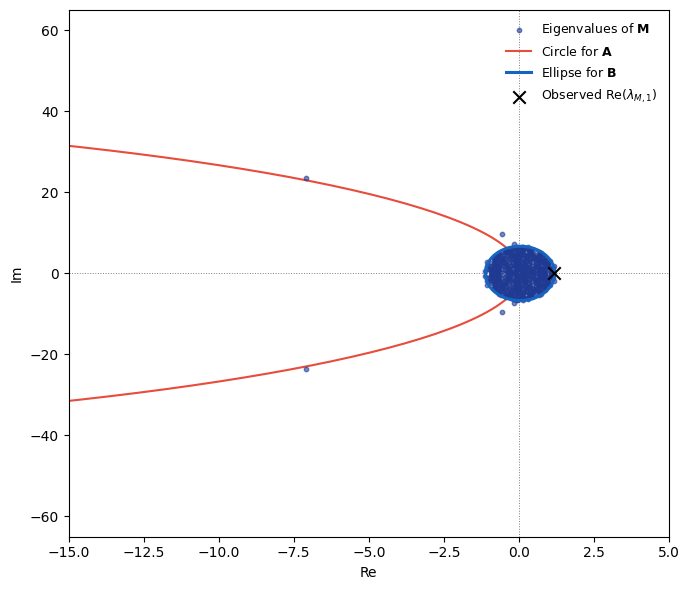

In [34]:

S, C, seed = 500, 0.25, 0

rng = np.random.default_rng(seed)
sampler = default_bivariate_sampler()

K = cascade_model(S, C, rng)
M = build_M_from_K(K, sampler, rng)

mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
r_A, c_A, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
r_h_B, r_v_B           = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
obs, eigvals            = leading_eigenvalue_real_part(M)
pred                    = re_lambda_A1 + r_h_B

print(f"Re(λ_M,1) osservato = {obs:.4f}  |  predetto = {pred:.4f}")


fig, ax = plt.subplots(figsize=(7, 6))
theta = np.linspace(0, 2 * np.pi, 400)

ax.scatter(eigvals.real, eigvals.imag, s=10, c='#1f3a93',
           alpha=0.6, label=r'Eigenvalues of $\mathbf{M}$', zorder=3)
ax.plot(c_A + r_A * np.cos(theta), r_A * np.sin(theta),
        color='#e74c3c', linewidth=1.5, label=r'Circle for $\mathbf{A}$')
ax.plot(re_lambda_A1 + r_h_B * np.cos(theta), r_v_B * np.sin(theta),
        color='#1565c0', linewidth=2.2, label=r'Ellipse for $\mathbf{B}$', zorder=5)
ax.scatter([obs], [0], color='black', marker='x', s=80, zorder=6,
           label=r'Observed Re($\lambda_{M,1}$)')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')

ax.set_xlabel('Re');  ax.set_ylabel('Im')
ax.legend(frameon=False, loc='upper right', fontsize=9)
ax.set_xlim(-15, 5);  ax.set_ylim(-65, 65)
fig.tight_layout()
plt.show()


## Figure 2 — Predicted vs Observed Re(λ₁) + spectra in the complex plane

Six panels as in the original Fig. 2:
- **(a,b,c)** scatter of predicted vs observed for cascade, niche, and empirical food webs
- **(d,e,f)** spectra in the complex plane for one example of each type

Parameters: `n_cascade=60`, `n_niche=30`, `n_empirical=15×10`.
Increase `n_cascade` and `n_niche` up to 150 to exactly replicate the paper.


  [cascade]   1/50  S=1000  C=0.154  obs=1.314  pred=1.296
  [cascade]   2/50  S=750  C=0.206  obs=1.331  pred=1.299
  [cascade]   3/50  S=750  C=0.203  obs=1.315  pred=1.292
  [cascade]   4/50  S=1000  C=0.170  obs=1.320  pred=1.355
  [cascade]   5/50  S=500  C=0.242  obs=1.093  pred=1.171
  [cascade]   6/50  S=1000  C=0.180  obs=1.441  pred=1.393
  [cascade]   7/50  S=1000  C=0.201  obs=1.476  pred=1.471
  [cascade]   8/50  S=500  C=0.250  obs=1.127  pred=1.181
  [cascade]   9/50  S=1000  C=0.189  obs=1.390  pred=1.422
  [cascade]  10/50  S=500  C=0.156  obs=0.898  pred=0.926
  [cascade]  11/50  S=500  C=0.296  obs=1.278  pred=1.286
  [cascade]  12/50  S=1000  C=0.276  obs=1.691  pred=1.727
  [cascade]  13/50  S=750  C=0.165  obs=1.110  pred=1.161
  [cascade]  14/50  S=750  C=0.150  obs=1.073  pred=1.100
  [cascade]  15/50  S=500  C=0.269  obs=1.212  pred=1.225
  [cascade]  16/50  S=500  C=0.286  obs=1.261  pred=1.269
  [cascade]  17/50  S=750  C=0.163  obs=1.124  pred=1.149
  [casca

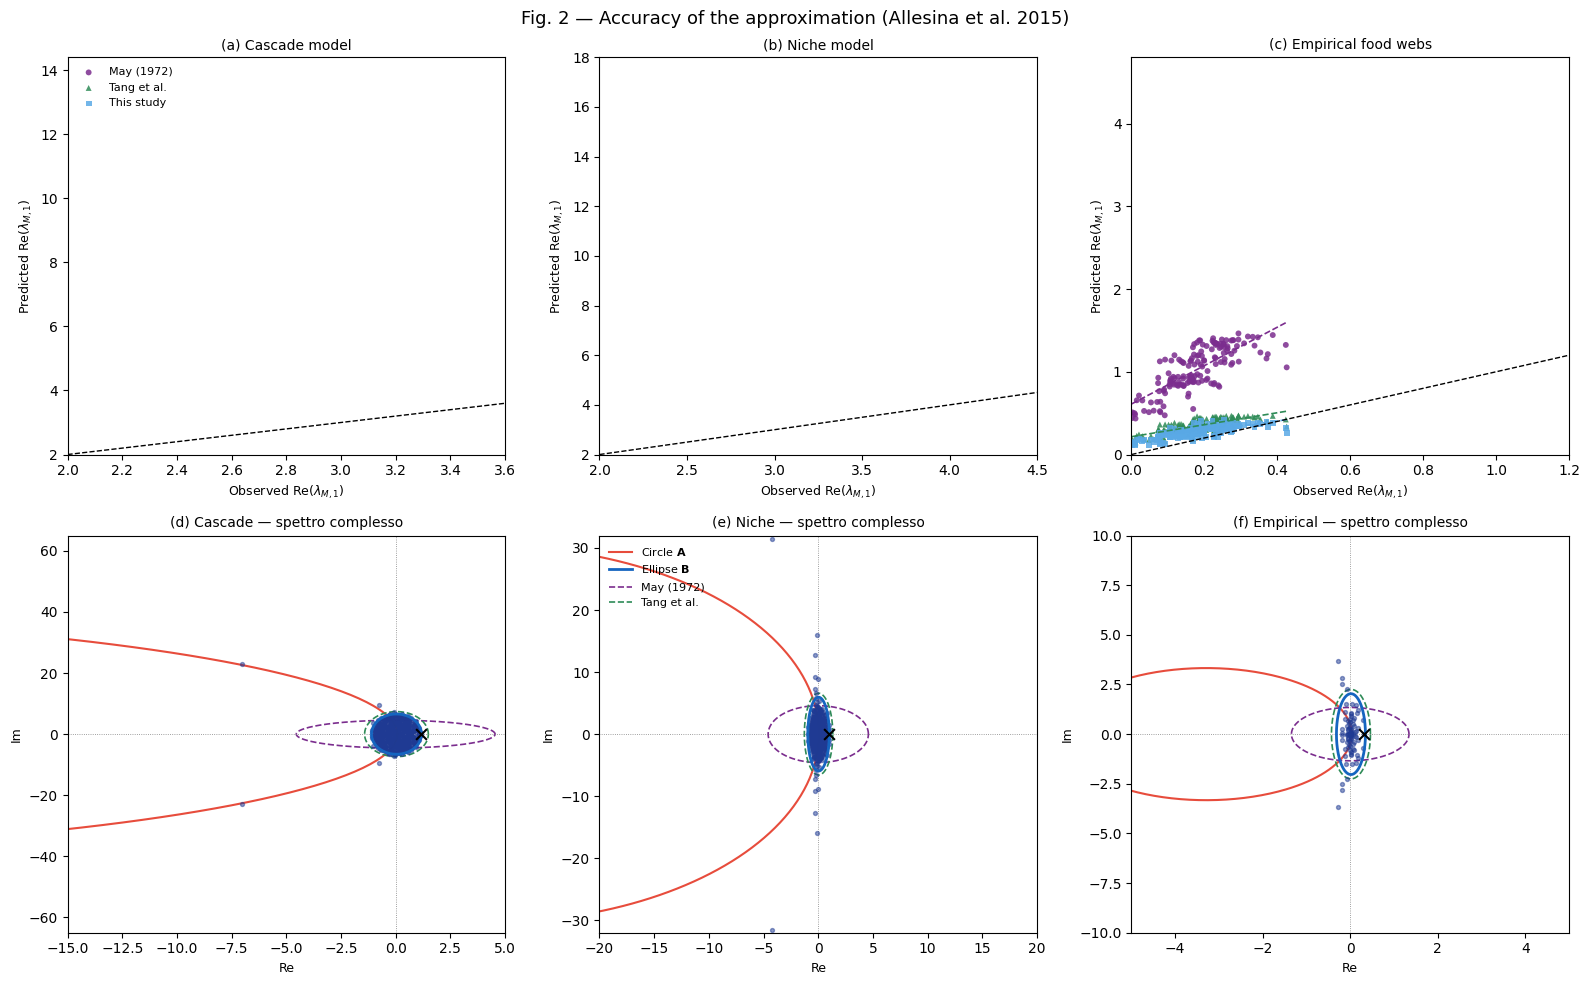

In [39]:
N_CASCADE  = 50    # 150
N_NICHE    = 50    # 150
N_PARAM    = 10    
SEED       = 0

EMPIRICAL_FOOD_WEBS = [
    ("Ythan Estuary",       82,  0.059),
    ("Silwood Park",        154, 0.030),
    ("El Verde",            155, 0.065),
    ("Canton Creek",        108, 0.067),
    ("Stony Stream",        112, 0.065),
    ("Chesapeake Bay",       33, 0.071),
    ("St. Marks",            48, 0.095),
    ("St. Martin Island",    44, 0.116),
    ("Skipwith Pond",        35, 0.315),
    ("Bridge Brook Lake",    25, 0.167),
    ("Little Rock Lake",     92, 0.118),
    ("Mirror Lake",         172, 0.062),
    ("Coachella Valley",     29, 0.312),
    ("Grassland",            61, 0.026),
    ("Benguela Current",     29, 0.260),
]

def run_simulation(model_func, n_matrices, rng, sampler,
                   reorder=False, label=""):
    obs_l, pred_l, tang_l, may_l = [], [], [], []
    for t in range(n_matrices):
        S = int(rng.choice([500, 750, 1000]))
        C = rng.uniform(0.1, 0.3)
        K = model_func(S, C, rng)
        if reorder:
            order = most_upper_triangular_order(K)
            K = K[np.ix_(order, order)]
        M = build_M_from_K(K, sampler, rng)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        obs, _ = leading_eigenvalue_real_part(M)
        pred    = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        nz      = M[M != 0]
        may     = may_criterion(S, C, np.abs(nz).mean(), nz.var())
        tang = tang_criterion(S, C, mu_U, mu_L, sigma_U2/C, sigma_L2/C, rho_UL=-0.67)

        obs_l.append(obs); pred_l.append(pred)
        tang_l.append(tang); may_l.append(may)
        print(f"  [{label}] {t+1:3d}/{n_matrices}  S={S}  C={C:.3f}  obs={obs:.3f}  pred={pred:.3f}")
    return map(np.array, [obs_l, pred_l, tang_l, may_l])

rng     = np.random.default_rng(SEED)
sampler = default_bivariate_sampler()


obs_c, pred_c, tang_c, may_c = run_simulation(
    cascade_model, N_CASCADE, rng, sampler, reorder=False, label="cascade")

print("\n=== Niche model ===")
obs_n, pred_n, tang_n, may_n = run_simulation(
    niche_model, N_NICHE, rng, sampler, reorder=True, label="niche")

print("\n=== Empirical food webs ===")
obs_e_l, pred_e_l, tang_e_l, may_e_l = [], [], [], []
for (name, S, C) in EMPIRICAL_FOOD_WEBS:
    K = niche_model(S, C, rng)
    order = most_upper_triangular_order(K)
    K_r = K[np.ix_(order, order)]
    for rep in range(N_PARAM):
        M = build_M_from_K(K_r, sampler, rng)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        obs, _ = leading_eigenvalue_real_part(M)
        pred    = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        nz      = M[M != 0]
        may     = may_criterion(S, C, np.abs(nz).mean(), nz.var())
        tang = tang_criterion(S, C, mu_U, mu_L, sigma_U2/C, sigma_L2/C, rho_UL=-0.67)

        obs_e_l.append(obs); pred_e_l.append(pred)
        tang_e_l.append(tang); may_e_l.append(may)
        print(f"  [empirical] {name:20s} rep={rep+1}  obs={obs:.3f}  pred={pred:.3f}")
obs_e, pred_e, tang_e, may_e = map(np.array, [obs_e_l, pred_e_l, tang_e_l, may_e_l])


def compute_spectrum_example(model_func, S=500, C=0.25, reorder=False, seed=1):
    rng_ = np.random.default_rng(seed)
    K = model_func(S, C, rng_)
    if reorder:
        order = most_upper_triangular_order(K)
        K = K[np.ix_(order, order)]
    M = build_M_from_K(K, sampler, rng_)
    mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
    r_A, c_A, re_lA1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, r_v_B     = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    obs, eigvals      = leading_eigenvalue_real_part(M)

    nz = M[M != 0]
    r_may = may_criterion(S, C, np.abs(nz).mean(), nz.var())

    rho_tang = -0.67
    sigma_tang = np.sqrt((sigma_U2 / C + sigma_L2 / C) / 2.0)
    mu_tang = (mu_U + mu_L) / 2.0
    r_h_tang = np.sqrt(S * C) * sigma_tang * (1.0 + rho_tang)
    r_v_tang = np.sqrt(S * C) * sigma_tang * (1.0 - rho_tang)
    c_tang = -mu_tang

    return (eigvals, r_A, c_A, re_lA1, r_h_B, r_v_B, obs,
            r_may, r_h_tang, r_v_tang, c_tang)

S_emp, C_emp = 92, 0.118
rng_emp = np.random.default_rng(99)
K_emp = niche_model(S_emp, C_emp, rng_emp)
order_emp = most_upper_triangular_order(K_emp)
K_emp_r = K_emp[np.ix_(order_emp, order_emp)]
M_emp = build_M_from_K(K_emp_r, sampler, rng_emp)
mu_U_e, mu_L_e, s2U_e, s2L_e, rho_e = triangular_stats(M_emp)
r_A_e, c_A_e, re_lA1_e = spectrum_A_params(S_emp, mu_U_e, mu_L_e)
r_h_B_e, r_v_B_e        = spectrum_B_params(S_emp, s2U_e, s2L_e, rho_e)
obs_emp, eigvals_emp     = leading_eigenvalue_real_part(M_emp)

nz_emp = M_emp[M_emp != 0]
r_may_e = may_criterion(S_emp, C_emp, np.abs(nz_emp).mean(), nz_emp.var())
rho_tang_e = -0.67
sigma_tang_e = np.sqrt((s2U_e / C_emp + s2L_e / C_emp) / 2.0)
mu_tang_e = (mu_U_e + mu_L_e) / 2.0
r_h_tang_e = np.sqrt(S_emp * C_emp) * sigma_tang_e * (1.0 + rho_tang_e)
r_v_tang_e = np.sqrt(S_emp * C_emp) * sigma_tang_e * (1.0 - rho_tang_e)
c_tang_e = -mu_tang_e

eigvals_c, r_A_c, c_A_c, re_lA1_c, r_h_B_c, r_v_B_c, obs_c_ex, \
    r_may_c, r_h_tang_c, r_v_tang_c, c_tang_c = \
    compute_spectrum_example(cascade_model, reorder=False, seed=1)
eigvals_ni, r_A_ni, c_A_ni, re_lA1_ni, r_h_B_ni, r_v_B_ni, obs_ni_ex, \
    r_may_ni, r_h_tang_ni, r_v_tang_ni, c_tang_ni = \
    compute_spectrum_example(niche_model, reorder=True, seed=1)


def scatter_panel(ax, obs, pred, tang, may, xlim, title):
    def fp(x, y, color, label, marker):
        ax.scatter(x, y, s=18, c=color, label=label, marker=marker,
                   alpha=0.85, edgecolors='none')
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(coef, xs), color=color, ls='--', lw=1.2)
    fp(obs, may,  '#7b2d8e', 'May (1972)', 'o')
    fp(obs, tang, '#2e8b57', 'Tang et al.', '^')
    fp(obs, pred, '#5aa9e6', 'This study', 's')
    ax.plot(list(xlim), list(xlim), 'k--', lw=1)
    ax.set_xlim(xlim); ax.set_ylim(xlim[0], xlim[1]*4)
    ax.set_xlabel(r'Observed Re($\lambda_{M,1}$)', fontsize=9)
    ax.set_ylabel(r'Predicted Re($\lambda_{M,1}$)', fontsize=9)
    ax.set_title(title, fontsize=10)

def spectrum_panel(ax, eigvals, r_A, c_A, re_lA1, r_h_B, r_v_B, obs_val,
                    r_may, r_h_tang, r_v_tang, c_tang,
                    xlim, ylim, title):
    theta = np.linspace(0, 2*np.pi, 400)
    ax.scatter(eigvals.real, eigvals.imag, s=8, c='#1f3a93', alpha=0.5, zorder=3)
    ax.plot(c_A + r_A*np.cos(theta), r_A*np.sin(theta),
            color='#e74c3c', lw=1.5, label=r'Circle $\mathbf{A}$')
    ax.plot(re_lA1 + r_h_B*np.cos(theta), r_v_B*np.sin(theta),
            color='#1565c0', lw=2, label=r'Ellipse $\mathbf{B}$', zorder=5)
    ax.plot(r_may*np.cos(theta), r_may*np.sin(theta),
            color='#7b2d8e', lw=1.2, ls='--', label='May (1972)')
    ax.plot(c_tang + r_h_tang*np.cos(theta), r_v_tang*np.sin(theta),
            color='#2e8b57', lw=1.2, ls='--', label='Tang et al.')
    ax.scatter([obs_val], [0], color='black', marker='x', s=60, zorder=6)
    ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_xlabel('Re', fontsize=9); ax.set_ylabel('Im', fontsize=9)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_panel(axes[0,0], obs_c,  pred_c,  tang_c,  may_c,  (2, 3.6),
              '(a) Cascade model')
scatter_panel(axes[0,1], obs_n,  pred_n,  tang_n,  may_n,  (2, 4.5),
              '(b) Niche model')
scatter_panel(axes[0,2], obs_e,  pred_e,  tang_e,  may_e,  (0.0, 1.2),
              '(c) Empirical food webs')
axes[0,0].legend(frameon=False, loc='upper left', fontsize=8)

spectrum_panel(axes[1,0], eigvals_c,  r_A_c,  c_A_c,  re_lA1_c,
               r_h_B_c,  r_v_B_c,  obs_c_ex,
               r_may_c, r_h_tang_c, r_v_tang_c, c_tang_c,
               (-15,5), (-65,65),
               '(d) Cascade — spettro complesso')
spectrum_panel(axes[1,1], eigvals_ni, r_A_ni, c_A_ni, re_lA1_ni,
               r_h_B_ni, r_v_B_ni, obs_ni_ex,
               r_may_ni, r_h_tang_ni, r_v_tang_ni, c_tang_ni,
               (-20,20), (-32,32),
               '(e) Niche — spettro complesso')
spectrum_panel(axes[1,2], eigvals_emp, r_A_e, c_A_e, re_lA1_e,
               r_h_B_e,  r_v_B_e,  obs_emp,
               r_may_e, r_h_tang_e, r_v_tang_e, c_tang_e,
               (-5,5),  (-10,10),
               '(f) Empirical — spettro complesso')
axes[1,1].legend(frameon=False, loc='upper left', fontsize=8)

fig.suptitle('Fig. 2 — Accuracy of the approximation (Allesina et al. 2015)',
             fontsize=13)
fig.tight_layout()
plt.show()

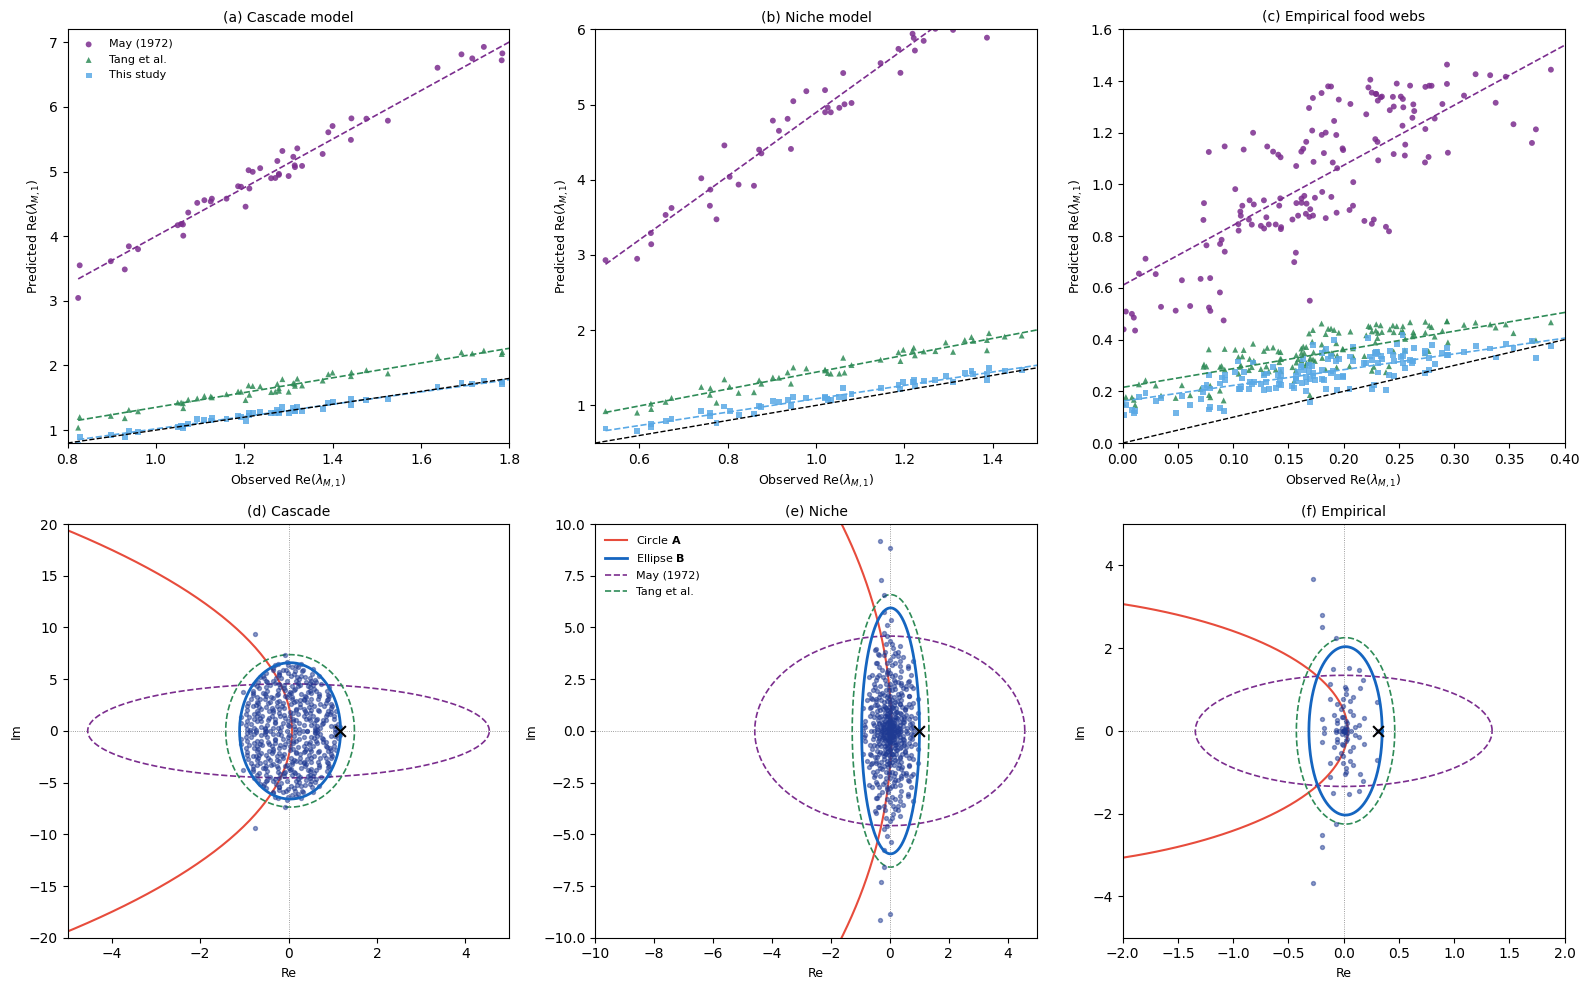

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_panel(axes[0,0], obs_c,  pred_c,  tang_c,  may_c,  (0.8, 1.8),
              '(a) Cascade model')
scatter_panel(axes[0,1], obs_n,  pred_n,  tang_n,  may_n,  (0.5, 1.5),
              '(b) Niche model')
scatter_panel(axes[0,2], obs_e,  pred_e,  tang_e,  may_e,  (0.0, 0.4),
              '(c) Empirical food webs')
axes[0,0].legend(frameon=False, loc='upper left', fontsize=8)

spectrum_panel(axes[1,0], eigvals_c,  r_A_c,  c_A_c,  re_lA1_c,
               r_h_B_c,  r_v_B_c,  obs_c_ex,
               r_may_c, r_h_tang_c, r_v_tang_c, c_tang_c,
               (-5,5), (-20,20),
               '(d) Cascade')
spectrum_panel(axes[1,1], eigvals_ni, r_A_ni, c_A_ni, re_lA1_ni,
               r_h_B_ni, r_v_B_ni, obs_ni_ex,
               r_may_ni, r_h_tang_ni, r_v_tang_ni, c_tang_ni,
               (-10,5), (-10,10),
               '(e) Niche')
spectrum_panel(axes[1,2], eigvals_emp, r_A_e, c_A_e, re_lA1_e,
               r_h_B_e,  r_v_B_e,  obs_emp,
               r_may_e, r_h_tang_e, r_v_tang_e, c_tang_e,
               (-2,2),  (-5,5),
               '(f) Empirical')
axes[1,1].legend(frameon=False, loc='upper left', fontsize=8)


fig.tight_layout()
plt.show()

## Figure 3 — Cascade model variants

Comparison of four structural variants: cascade with niche-model degree distribution,
interval cascade, cascade with both properties (= niche model without cycles), niche model.
Reproduction of Fig. 3 from Allesina et al. (2015).

`n_matrices=30` for speed; increase to 150 to replicate the paper.


Saved fig3_reproduction.png


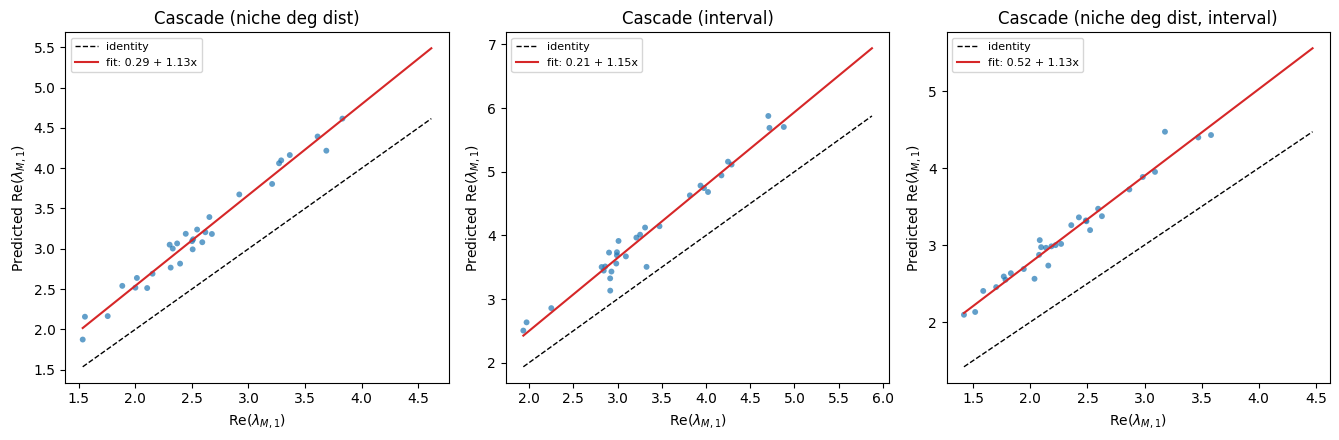

In [ ]:

def cascade_model_f3(S, C, rng):
    K = np.zeros((S, S), dtype=bool)
    for j in range(1, S):
        K[:j, j] = rng.random(j) < C
    return K




def niche_model_f3(S, C, rng, max_attempts=50):

    beta = max(1.0 / C - 1.0, 1e-6)
    expected_links = C * S * (S - 1) / 2.0
    std_links = np.sqrt(expected_links * (1 - C))

    K_best, diff_best = None, np.inf
    for _ in range(max_attempts):

        n = np.sort(rng.random(S))
        r = n * rng.beta(1.0, beta, size=S)
        lo_c = r / 2.0
        hi_c = np.minimum(n, 1.0 - r / 2.0)
        hi_c = np.maximum(hi_c, lo_c)
        c = rng.uniform(lo_c, hi_c)

        low, high = c - r / 2.0, c + r / 2.0

        K = np.zeros((S, S), dtype=bool)
        for j in range(S):
            prey = np.where((n >= low[j]) & (n <= high[j]))[0]
            prey = prey[prey != j]
            K[prey, j] = True

        iu = np.triu_indices(S, k=1)
        double = K[iu[0], iu[1]] & K[iu[1], iu[0]]
        for i, j in zip(iu[0][double], iu[1][double]):
            if rng.random() < 0.5:
                K[i, j] = False
            else:
                K[j, i] = False

        n_links = K.sum()
        diff = abs(n_links - expected_links)
        if diff < diff_best:
            K_best, diff_best = K, diff
        if diff <= 2 * std_links and _is_weakly_connected(K):
            return K

    return K_best


def _niche_like_degrees(S, C, rng):
    beta = max(1.0 / C - 1.0, 1e-6)
    eta = np.sort(rng.random(S))
    B = rng.beta(1.0, beta, size=S)
    return eta * B


def cascade_with_niche_degdist(S, C, rng):
    r = _niche_like_degrees(S, C, rng)
    K = np.zeros((S, S), dtype=bool)
    for j in range(1, S):
        k = min(rng.binomial(j, r[j]), j)
        if k > 0:
            prey = rng.choice(j, size=k, replace=False)
            K[prey, j] = True
    return K


def cascade_interval_f3(S, C, rng, niche_degdist=False):
    if niche_degdist:
        r = _niche_like_degrees(S, C, rng)

    K = np.zeros((S, S), dtype=bool)
    for j in range(1, S):
        max_prey = j
        k = min(rng.binomial(max_prey, r[j] if niche_degdist else C), max_prey)
        if k > 0:
            start = rng.integers(0, max_prey - k + 1)
            K[start:start + k, j] = True
    return K


def build_M_f3(K, mx, my, sx, sy, rho, rng):
    S = K.shape[0]
    M = np.zeros((S, S))
    prey, pred = np.where(K)
    n_links = len(prey)
    cov = [[sx ** 2, rho * sx * sy], [rho * sx * sy, sy ** 2]]
    XY = rng.multivariate_normal([mx, my], cov, size=n_links)
    M[prey, pred] = XY[:, 0]
    M[pred, prey] = XY[:, 1]
    return M


def matrix_moments_f3(M):
    S = M.shape[0]
    iu, ju = np.triu_indices(S, k=1)
    U = M[iu, ju]
    L = M[ju, iu]
    mU, mL = U.mean(), L.mean()
    sU, sL = U.std(), L.std()
    if sU > 0 and sL > 0:
        rhoUL = np.corrcoef(U, L)[0, 1]
    else:
        rhoUL = 0.0
    return mU, mL, sU, sL, rhoUL


def re_lambda_A1_f3(S, mU, mL):
    A = np.empty((S, S))
    A.fill(mL)
    iu = np.triu_indices(S, k=1)
    A[iu] = mU
    np.fill_diagonal(A, 0.0)
    eig = np.linalg.eigvals(A)
    return eig.real.max()


def re_lambda_B1_f3(S, sU, sL, rhoUL):
    if sU <= 0 or sL <= 0:
        return 0.0
    if np.isclose(sU, sL):
        a = S * sU ** 2
    else:
        a = S * (sU ** 2 - sL ** 2) / np.log(sU ** 2 / sL ** 2)
    rh = (a + rhoUL * sU * sL * (S - 1)) / np.sqrt(a)
    return rh


def predict_re_lambda_M1_f3(K, mx, my, sx, sy, rho, rng):
    S = K.shape[0]
    M = build_M_f3(K, mx, my, sx, sy, rho, rng)
    mU, mL, sU, sL, rhoUL = matrix_moments_f3(M)
    reA = re_lambda_A1_f3(S, mU, mL)
    reB = re_lambda_B1_f3(S, sU, sL, rhoUL)
    predicted = reA + reB
    observed = np.linalg.eigvals(M).real.max()
    return predicted, observed


def run_panel(model_name, n_networks, S_choices, C_range, Z_params, rng):
    mx, my, sx, sy, rho = Z_params
    predicted_list, observed_list = [], []
    for _ in range(n_networks):
        S = int(rng.choice(S_choices))
        C = rng.uniform(*C_range)

        if model_name == "cascade_niche_degdist":
            K = cascade_with_niche_degdist(S, C, rng)

        elif model_name == "cascade_interval":
            K = cascade_interval_f3(S, C, rng, niche_degdist=False)

        elif model_name == "cascade_niche_degdist_interval":
            K = cascade_interval_f3(S, C, rng, niche_degdist=True)

        else:
            raise ValueError(model_name)

        pred, obs = predict_re_lambda_M1_f3(K, mx, my, sx, sy, rho, rng)
        predicted_list.append(pred)
        observed_list.append(obs)

    return np.array(observed_list), np.array(predicted_list)


rng = np.random.default_rng(42)
Z_PARAMS = dict(mx=-1.0, my=0.35, sx=1.23, sy=0.46, rho=-0.67)
S_CHOICES = [500, 750, 1000]
C_RANGE = (0.1, 0.3)
N_NETWORKS = 30  # paper uses ~150; reduce for speed, increase for fidelity

panels = [
    ("cascade_niche_degdist", "Cascade (niche deg dist)"),
    ("cascade_interval", "Cascade (interval)"),
    ("cascade_niche_degdist_interval", "Cascade (niche deg dist, interval)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
axes = axes.ravel()

for ax, (key, title) in zip(axes, panels):
    obs, pred = run_panel(key, N_NETWORKS, S_CHOICES, C_RANGE,
                            tuple(Z_PARAMS.values()), rng)

    ax.scatter(obs, pred, s=18, alpha=0.7, edgecolor="none")

    lo = min(obs.min(), pred.min())
    hi = max(obs.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")

    coeffs = np.polyfit(obs, pred, 1)
    xs = np.linspace(lo, hi, 50)
    ax.plot(xs, np.polyval(coeffs, xs), "-", lw=1.5, color="tab:red",
            label=f"fit: {coeffs[1]:.2f} + {coeffs[0]:.2f}x")

    ax.set_title(title)
    ax.set_xlabel(r"Re($\lambda_{M,1}$)")
    ax.set_ylabel(r"Predicted Re($\lambda_{M,1}$)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig3_reproduction.png", dpi=150)
print("Saved fig3_reproduction.png")

Saved fig3_reproduction.png


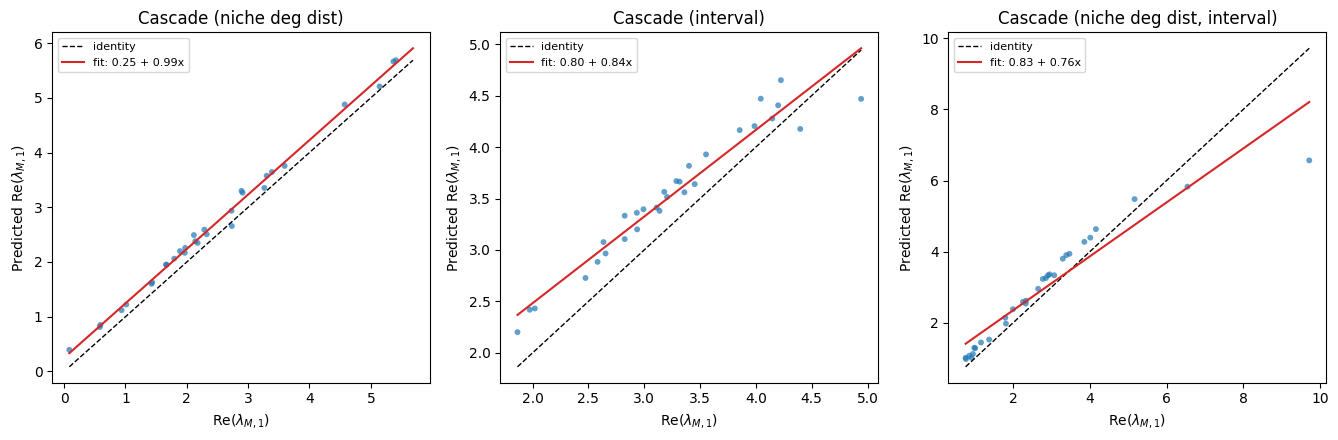

In [50]:
"""def _niche_like_degrees(S, C, rng):
    beta = max(1.0 / C - 1.0, 1e-6)
    eta = np.sort(rng.random(S))
    r = np.zeros(S)
    for j in range(S):
        B_j = rng.beta(1.0, beta)
        r[j] = eta[j] * B_j
    return r
"""
def _niche_like_degrees(S, C, rng):
    beta = max(1.0 / C - 1.0, 1e-6)
    eta = np.sort(rng.random(S))
    B = rng.beta(1.0, beta)     
    r = np.zeros(S)
    for j in range(S):
        r[j] = eta[j] * B
    return r
    
def cascade_with_niche_degdist(S, C, rng):
    r = _niche_like_degrees(S, C, rng)
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        k = rng.binomial(j, r[j])
        if k > 0:
            prey = rng.choice(j, size=k, replace=False)
            for i in prey:
                K[i, j] = 1
    return K


def cascade_interval_niche(S, C, rng, niche_degdist=False):
    if niche_degdist:
        r = _niche_like_degrees(S, C, rng)

    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        max_prey = j
        p = r[j] if niche_degdist else C
        k = rng.binomial(max_prey, p)
        if k > max_prey:
            k = max_prey
        if k > 0:
            start = rng.integers(0, max_prey - k + 1)
            for i in range(start, start + k):
                K[i, j] = 1
    return K


def run_panel(model_name, n_networks, S_choices, C_range, sampler, rng):
    predicted_list = []
    observed_list = []

    for _ in range(n_networks):
        S = int(rng.choice(S_choices))
        C = rng.uniform(C_range[0], C_range[1])

        if model_name == "cascade_niche_degdist":
            K = cascade_with_niche_degdist(S, C, rng)
        elif model_name == "cascade_interval":
            K = cascade_interval_niche(S, C, rng, niche_degdist=False)
        elif model_name == "cascade_niche_degdist_interval":
            K = cascade_interval_niche(S, C, rng, niche_degdist=True)
        else:
            raise ValueError(model_name)

        M = build_M_from_K(K, sampler, rng)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        pred = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        obs = np.linalg.eigvals(M).real.max()

        predicted_list.append(pred)
        observed_list.append(obs)

    return np.array(observed_list), np.array(predicted_list)


rng = np.random.default_rng(42)
sampler = default_bivariate_sampler(mu_x=-1.0, mu_y=0.35,
                                     sigma_x=1.23, sigma_y=0.46, rho_xy=-0.67)

S_CHOICES = [500, 750, 1000]
C_RANGE = (0.1, 0.3)
N_NETWORKS = 30  # paper uses ~150; reduce for speed, increase for fidelity

panels = [
    ("cascade_niche_degdist", "Cascade (niche deg dist)"),
    ("cascade_interval", "Cascade (interval)"),
    ("cascade_niche_degdist_interval", "Cascade (niche deg dist, interval)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
axes = axes.ravel()

for ax, (key, title) in zip(axes, panels):
    obs, pred = run_panel(key, N_NETWORKS, S_CHOICES, C_RANGE, sampler, rng)

    ax.scatter(obs, pred, s=18, alpha=0.7, edgecolor="none")

    lo = min(obs.min(), pred.min())
    hi = max(obs.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")

    coeffs = np.polyfit(obs, pred, 1)
    xs = np.linspace(lo, hi, 50)
    ax.plot(xs, np.polyval(coeffs, xs), "-", lw=1.5, color="tab:red",
            label=f"fit: {coeffs[1]:.2f} + {coeffs[0]:.2f}x")

    ax.set_title(title)
    ax.set_xlabel(r"Re($\lambda_{M,1}$)")
    ax.set_ylabel(r"Predicted Re($\lambda_{M,1}$)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig3_reproduction.png", dpi=150)
print("Saved fig3_reproduction.png")

## Figure 4 — Sensitivity analysis

Predicted Re(λ_M,1) as each parameter is varied (multiplied by θ),
with all other parameters fixed at their base value.
Reproduction of Fig. 4 from Allesina et al. (2015).


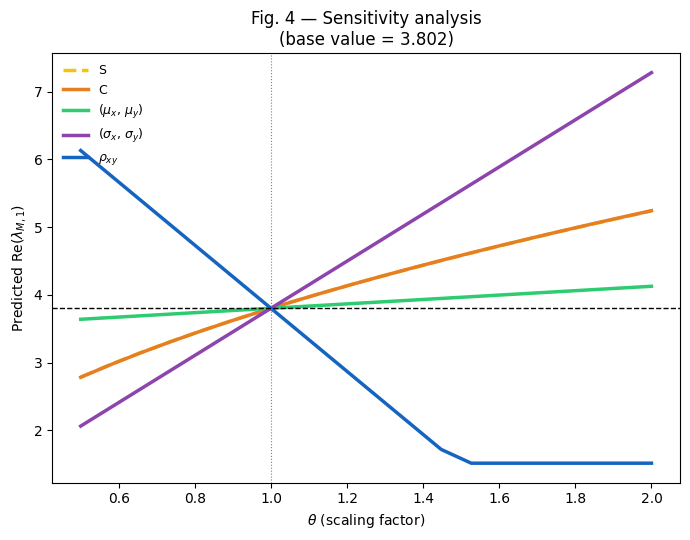

In [51]:
S0, C0         = 1000, 0.1
mu_x0, mu_y0   = -1.0, 0.35
sigma_x0, sigma_y0 = 1.23, 0.46
rho_xy0        = -0.67

theta_values = np.linspace(0.5, 2.0, 20)

def calc(S=S0, C=C0, mu_x=mu_x0, mu_y=mu_y0,
         sigma_x=sigma_x0, sigma_y=sigma_y0, rho_xy=rho_xy0):
    return re_lambda_M1_from_Z_params(S, C, mu_x, mu_y, sigma_x, sigma_y, rho_xy)

curves = {
    'S':                      [calc(S=int(round(S0*th))) for th in theta_values],
    'C':                      [calc(C=min(C0*th, 0.999)) for th in theta_values],
    r'($\mu_x$, $\mu_y$)':   [calc(mu_x=mu_x0*th, mu_y=mu_y0*th) for th in theta_values],
    r'($\sigma_x$, $\sigma_y$)': [calc(sigma_x=sigma_x0*th, sigma_y=sigma_y0*th) for th in theta_values],
    r'$\rho_{xy}$':           [calc(rho_xy=np.clip(rho_xy0*th, -0.999, 0.999)) for th in theta_values],
}
base_value = calc()

colors_map = {
    'S':                       '#f1c40f',
    'C':                       '#e67e22',
    r'($\mu_x$, $\mu_y$)':    '#2ecc71',
    r'($\sigma_x$, $\sigma_y$)': '#8e44ad',
    r'$\rho_{xy}$':            '#1565c0',

}

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, ys in curves.items():
    ax.plot(theta_values, ys, label=label, color=colors_map[label],
            linewidth=2.5, linestyle=('--' if label=='S' else '-'))

ax.axhline(base_value, color='black', ls='--', lw=1)
ax.axvline(1.0,        color='gray',  ls=':',  lw=0.8)
ax.set_xlabel(r'$\theta$ (scaling factor)')
ax.set_ylabel(r'Predicted Re($\lambda_{M,1}$)')
ax.set_title(f'Fig. 4 — Sensitivity analysis\n(base value = {base_value:.3f})')
ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()



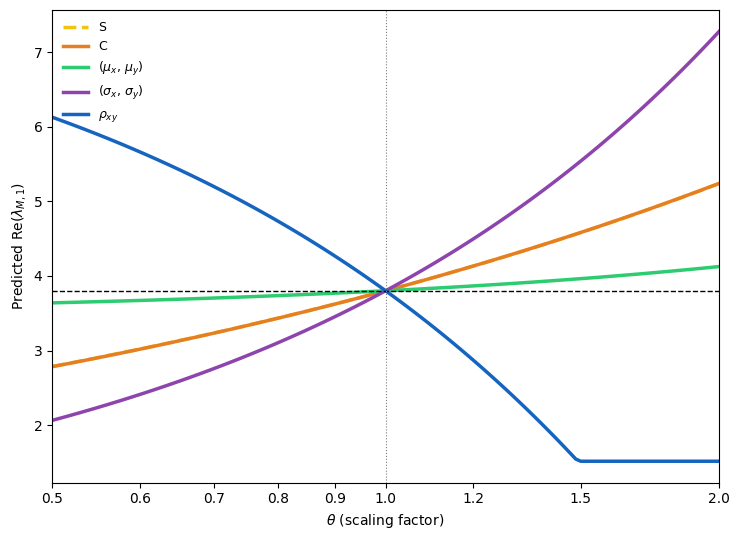

In [55]:

S0, C0         = 1000, 0.1
mu_x0, mu_y0   = -1.0, 0.35
sigma_x0, sigma_y0 = 1.23, 0.46
rho_xy0        = -0.67

theta_values = np.linspace(0.5, 2.0, 100)

def calc(S=S0, C=C0, mu_x=mu_x0, mu_y=mu_y0,
         sigma_x=sigma_x0, sigma_y=sigma_y0, rho_xy=rho_xy0):
    return re_lambda_M1_from_Z_params(S, C, mu_x, mu_y, sigma_x, sigma_y, rho_xy)

# Ricalcolo delle curve
curves = {
    'S':                      [calc(S=int(round(S0*th))) for th in theta_values],
    'C':                      [calc(C=min(C0*th, 0.999)) for th in theta_values],
    r'($\mu_x$, $\mu_y$)':   [calc(mu_x=mu_x0*th, mu_y=mu_y0*th) for th in theta_values],
    r'($\sigma_x$, $\sigma_y$)': [calc(sigma_x=sigma_x0*th, sigma_y=sigma_y0*th) for th in theta_values],
    r'$\rho_{xy}$':           [calc(rho_xy=np.clip(rho_xy0*th, -0.999, 0.999)) for th in theta_values],
}

base_value = calc()

# ==================== COLORE DICT ====================
colors_map = {
    'S':                       '#f1c40f',
    'C':                       '#e67e22',
    r'($\mu_x$, $\mu_y$)':    '#2ecc71',
    r'($\sigma_x$, $\sigma_y$)': '#8e44ad',
    r'$\rho_{xy}$':            '#1565c0',
}

# ==================== PLOT ====================
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for label, ys in curves.items():
    ax.plot(theta_values, ys, 
            label=label, 
            color=colors_map[label],
            linewidth=2.5, 
            linestyle=('--' if label == 'S' else '-'))

ax.axhline(base_value, color='black', ls='--', lw=1)
ax.axvline(1.0, color='gray', ls=':', lw=0.8)

ax.set_xscale('log')
ax.set_xlim(0.5, 2.0)

# Ticks personalizzati
ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0])
ax.set_xticklabels(['0.5', '0.6', '0.7', '0.8', '0.9', '1.0', '1.2', '1.5', '2.0'])

ax.set_xlabel(r'$\theta$ (scaling factor)')
ax.set_ylabel(r'Predicted Re($\lambda_{M,1}$)')

ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

τ niche originale:   0.964
τ niche riordinata:  0.827


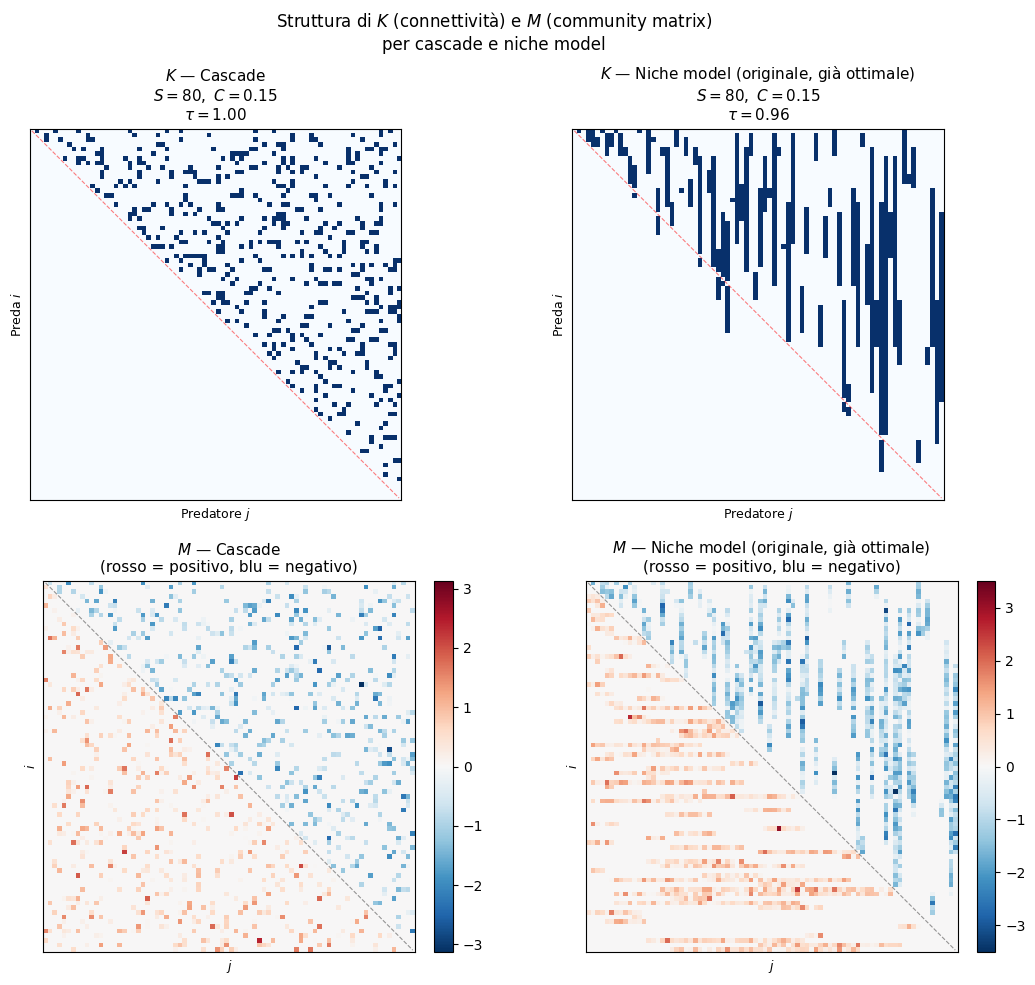

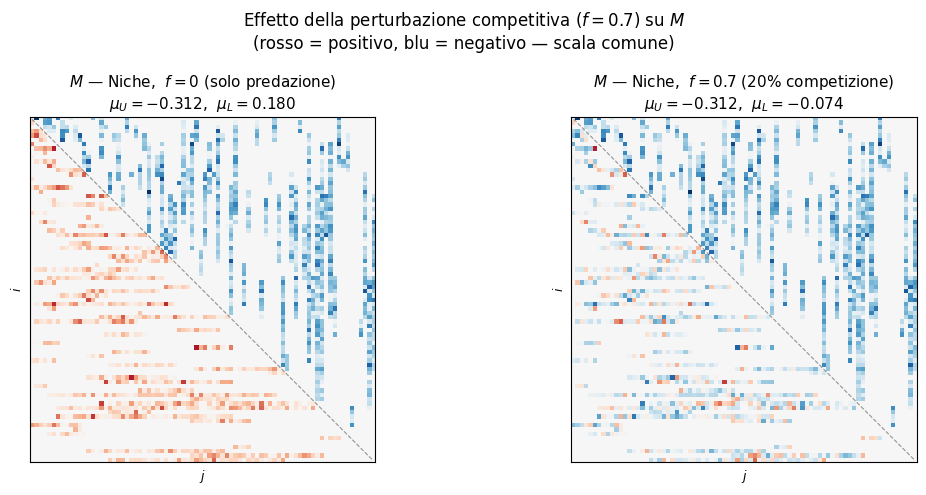

In [ ]:

def triangularity(K):
    S = K.shape[0]
    iu = np.triu_indices(S, k=1)
    il = np.tril_indices(S, k=-1)
    n_upper = K[iu].sum()
    n_lower = K[il].sum()
    total = n_upper + n_lower
    return n_upper / total if total > 0 else 0.5

S_PLOT, C_PLOT = 80, 0.15
SEED_PLOT = 3
rng_plot = np.random.default_rng(SEED_PLOT)
sampler  = default_bivariate_sampler()


K_cascade = cascade_model(S_PLOT, C_PLOT, rng_plot)
M_cascade = build_M_from_K(K_cascade, sampler, rng_plot)


K_niche = niche_model(S_PLOT, C_PLOT, rng_plot)
order   = most_upper_triangular_order(K_niche)
K_niche_ord = K_niche[np.ix_(order, order)]

tau_niche_raw = triangularity(K_niche)
tau_niche_ord = triangularity(K_niche_ord)
print(f"τ niche originale:   {tau_niche_raw:.3f}")
print(f"τ niche riordinata:  {tau_niche_ord:.3f}")

if tau_niche_ord >= tau_niche_raw:
    K_niche_best = K_niche_ord
    label_niche  = "Niche model (riordinata)"
else:
    K_niche_best = K_niche
    label_niche  = "Niche model (originale, già ottimale)"

M_niche = build_M_from_K(K_niche_best, sampler, rng_plot)


fig, axes = plt.subplots(2, 2, figsize=(11, 10))

def plot_K(ax, K, title):
    ax.imshow(K, cmap='Blues', interpolation='nearest', aspect='equal',
              vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predatore $j$', fontsize=9)
    ax.set_ylabel('Preda $i$',    fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, K.shape[1]-1], [0, K.shape[0]-1],
            color='red', lw=0.8, ls='--', alpha=0.5)

def plot_M(ax, M, title):
    vmax = np.abs(M).max()
    im = ax.imshow(M, cmap='RdBu_r', interpolation='nearest',
                   aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$j$', fontsize=9)
    ax.set_ylabel('$i$', fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, M.shape[1]-1], [0, M.shape[0]-1],
            color='black', lw=0.8, ls='--', alpha=0.4)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_K(axes[0, 0], K_cascade,
       f'$K$ — Cascade\n$S={S_PLOT},\\ C={C_PLOT}$\n$\\tau={triangularity(K_cascade):.2f}$')
plot_K(axes[0, 1], K_niche_best,
       f'$K$ — {label_niche}\n$S={S_PLOT},\\ C={C_PLOT}$\n$\\tau={triangularity(K_niche_best):.2f}$')

plot_M(axes[1, 0], M_cascade,
       '$M$ — Cascade\n(rosso = positivo, blu = negativo)')
plot_M(axes[1, 1], M_niche,
       f'$M$ — {label_niche}\n(rosso = positivo, blu = negativo)')

fig.suptitle(
    'Struttura di $K$ (connettività) e $M$ (community matrix)\n'
    'per cascade e niche model',
    fontsize=12
)
fig.tight_layout()
plt.show()


F_PERT = 0.4

def sampler_with_competition(f, base_sampler):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

sampler_f0  = sampler_with_competition(0.0,   default_bivariate_sampler())
sampler_f20 = sampler_with_competition(F_PERT, default_bivariate_sampler())

rng0  = np.random.default_rng(SEED_PLOT + 10)
rng20 = np.random.default_rng(SEED_PLOT + 10)

M_f0  = build_M_from_K(K_niche_best, sampler_f0,  rng0)
M_f20 = build_M_from_K(K_niche_best, sampler_f20, rng20)

vmax_pert = max(np.abs(M_f0).max(), np.abs(M_f20).max())

def plot_M_shared(ax, M, title, vmax):
    im = ax.imshow(M, cmap='RdBu_r', interpolation='nearest',
                   aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$j$', fontsize=9)
    ax.set_ylabel('$i$', fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, M.shape[1]-1], [0, M.shape[0]-1],
            color='black', lw=0.8, ls='--', alpha=0.4)
    return im

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))

iu = np.triu_indices(S_PLOT, k=1)
il = np.tril_indices(S_PLOT, k=-1)

im0  = plot_M_shared(axes2[0], M_f0,
                     f'$M$ — Niche,  $f=0$ (solo predazione)\n'
                     f'$\\mu_U={M_f0[iu].mean():.3f}$,  '
                     f'$\\mu_L={M_f0[il].mean():.3f}$',
                     vmax_pert)
im20 = plot_M_shared(axes2[1], M_f20,
                     f'$M$ — Niche,  $f={F_PERT}$ (20% competizione)\n'
                     f'$\\mu_U={M_f20[iu].mean():.3f}$,  '
                     f'$\\mu_L={M_f20[il].mean():.3f}$',
                     vmax_pert)

#fig2.colorbar(im20, ax=axes2.tolist(), fraction=0.02, pad=0.04)
fig2.suptitle(
    f'Effetto della perturbazione competitiva ($f={F_PERT}$) su $M$\n'
    '(rosso = positivo, blu = negativo — scala comune)',
    fontsize=12
)
fig2.tight_layout()
plt.show()

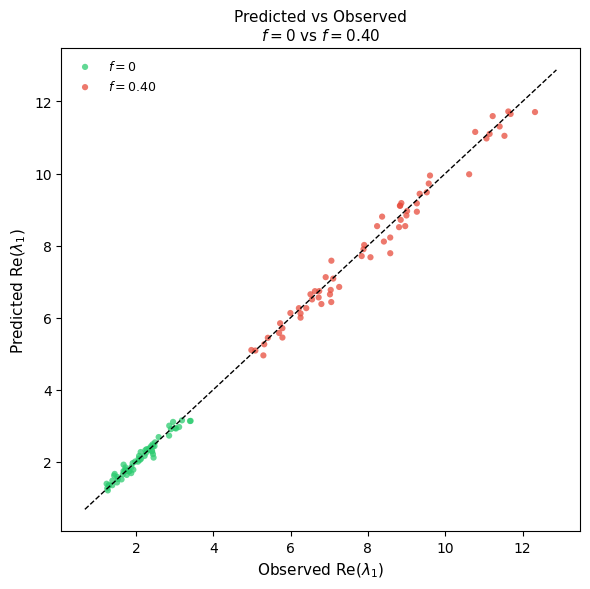

In [ ]:
rng = np.random.default_rng(SEED)
sampler = default_bivariate_sampler()

def sampler_with_competition(f, base_sampler, rng):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

fig, ax = plt.subplots(figsize=(6, 6))

for f_sel, color, label in [(0.0, '#2ecc71', '$f=0$'),
                             (0.40, '#e74c3c', '$f=0.40$')]:
    s_sel = sampler_with_competition(f_sel, sampler, rng)
    obs_l, pred_l = [], []
    rng2 = np.random.default_rng(0)
    for _ in range(60):
        S = int(rng2.choice([300, 500, 750]))
        C = rng2.uniform(0.1, 0.3)
        K = cascade_model(S, C, rng2)
        M = build_M_from_K(K, s_sel, rng2)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        ratio = (-mu_L / mu_U) if mu_U != 0 else np.nan
        if ratio <= 0 or np.isnan(ratio): continue
        obs, _ = leading_eigenvalue_real_part(M)
        pred   = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        obs_l.append(obs); pred_l.append(pred)
    ax.scatter(obs_l, pred_l, s=20, c=color, alpha=0.75,
               edgecolors='none', label=label)

lims = ax.get_xlim()
lo = min(lims[0], ax.get_ylim()[0])
hi = max(lims[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel(r'Observed Re($\lambda_1$)', fontsize=11)
ax.set_ylabel(r'Predicted Re($\lambda_1$)', fontsize=11)
ax.set_title('Predicted vs Observed\n$f=0$ vs $f=0.40$', fontsize=11)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

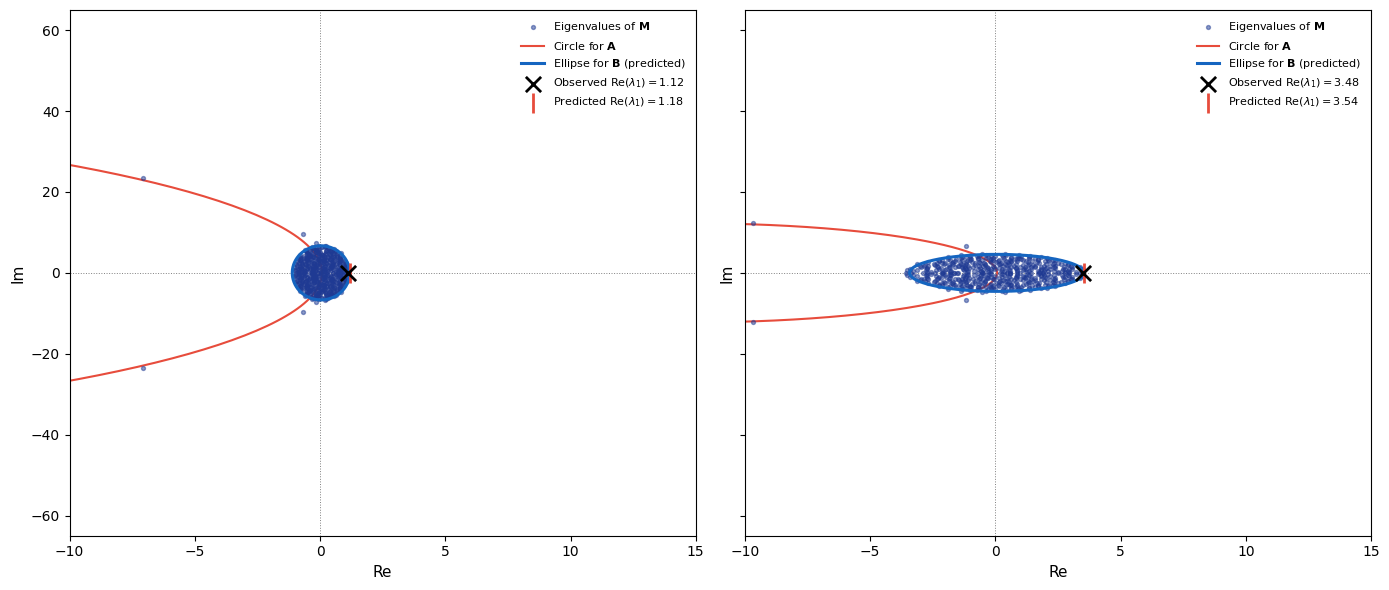

In [57]:
S, C, SEED = 500, 0.25, 0
F_COMPARE  = 0.4

def sampler_with_competition(f, base_sampler):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

base_sampler = default_bivariate_sampler()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
theta = np.linspace(0, 2 * np.pi, 400)

for ax, f in zip(axes, [0.0, F_COMPARE]):
    rng = np.random.default_rng(SEED)   # stesso seed: stessa K, stessa M a meno dei segni
    s_f = sampler_with_competition(f, base_sampler)

    K = cascade_model(S, C, rng)
    M = build_M_from_K(K, s_f, rng)

    mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
    r_A, c_A, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, r_v_B           = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    obs, eigvals            = leading_eigenvalue_real_part(M)
    pred                    = re_lambda_A1 + r_h_B

    ax.scatter(eigvals.real, eigvals.imag, s=8, c='#1f3a93',
               alpha=0.5, label=r'Eigenvalues of $\mathbf{M}$', zorder=3)
    ax.plot(c_A + r_A * np.cos(theta), r_A * np.sin(theta),
            color='#e74c3c', lw=1.5, label=r'Circle for $\mathbf{A}$')
    ax.plot(re_lambda_A1 + r_h_B * np.cos(theta), r_v_B * np.sin(theta),
            color='#1565c0', lw=2.2, label=r'Ellipse for $\mathbf{B}$ (predicted)', zorder=5)
    ax.scatter([obs],  [0], color='black',  marker='x', s=120, lw=2, zorder=7,
               label=fr'Observed $\mathrm{{Re}}(\lambda_1)={obs:.2f}$')
    ax.scatter([pred], [0], color='#e74c3c', marker='|', s=200, lw=2, zorder=6,
               label=fr'Predicted $\mathrm{{Re}}(\lambda_1)={pred:.2f}$')

    ax.axvline(0, color='gray', lw=0.7, ls=':')
    ax.axhline(0, color='gray', lw=0.7, ls=':')
    ax.set_xlabel('Re', fontsize=11)
    ax.set_ylabel('Im', fontsize=11)
    bias = pred - obs
    ax.legend(frameon=False, loc='upper right', fontsize=8)

for ax in axes:
    ax.set_xlim(-10, 15)
    ax.set_ylim(-65, 65)


fig.tight_layout()
plt.show()